In [1]:
import numpy as np
import pandas as pd
import os, os.path
from sklearn.preprocessing import MinMaxScaler

In [2]:
cities = ['Bordeaux', 'Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
         'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']

## Data input preparation

### Bordeaux

In [4]:
bordeaux = pd.read_csv('/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/citys/Bordeaux.csv')

In [5]:
bordeaux.drop('date_time', axis=1, inplace=True)

In [6]:
bordeaux.head()

,Google,Twitter,Netflix,DailyMotion,Deezer
0,1.455929e+09,3.945873e+08,2.594375e+09,2.921406e+08,8.016234e+08
1,1.194470e+09,5.488253e+08,2.925433e+09,2.749235e+08,9.393558e+08
2,1.330794e+09,4.159023e+08,2.730299e+09,5.556913e+08,9.708451e+08
3,1.371658e+09,3.711923e+08,3.658371e+09,2.508510e+08,8.707489e+08
4,1.219233e+09,4.042379e+08,2.319508e+09,5.302139e+08,1.016070e+09


In [7]:
bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)

In [8]:
    bordeaux = bordeaux.to_numpy()

In [9]:
bordeaux.shape

(17878, 5)

### Model

In [10]:
from tensorflow import keras
import tensorflow as tf
from keras import backend as K
from tensorflow.keras import layers, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

2025-03-06 11:42:02.888335: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-06 11:42:02.888538: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-06 11:42:02.889923: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-06 11:42:03.021115: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
XTRAIN = 2016*8 # lenght of training dataset
LOOKBACK = 6 # History given as input to the network. Could be modified if needed
DELAY = 6 # Lenght forecast
PHI = 10 # Negative slope of the loss function TO BE MODIFIED 
GAMMA = 2 # Positive slope of the loss function
NUM_SERV = bordeaux.shape[-1] # number of services
EPOCHS = 300 # training epochs
B = 100 # Number of montecarlo output

In [12]:
minmaxscaler = MinMaxScaler()
x_train = bordeaux[:XTRAIN]
x_train_norm = tf.convert_to_tensor(minmaxscaler.fit_transform(x_train), dtype=tf.float32)
x_test = bordeaux[XTRAIN:]
x_test_norm = tf.convert_to_tensor(minmaxscaler.transform(x_test), dtype=tf.float32)

2025-03-06 11:42:13.841496: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79183 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0
2025-03-06 11:42:13.843662: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 4079 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:81:00.0, compute capability: 8.0
2025-03-06 11:42:13.845547: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 75173 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:e2:00.0, compute capability: 8.0


In [13]:
input_dataset = keras.preprocessing.timeseries_dataset_from_array(x_train_norm[:-DELAY], None,
                                                                  sequence_length=LOOKBACK, sequence_stride=DELAY)
target_dataset = keras.preprocessing.timeseries_dataset_from_array(x_train_norm[LOOKBACK:], None,
                                                                   sequence_length=DELAY, sequence_stride=DELAY)

In [14]:
test_dataset = keras.preprocessing.timeseries_dataset_from_array(x_test_norm[:-DELAY], None,
                                                                 sequence_length=LOOKBACK, sequence_stride=DELAY,
                                                                 batch_size=128)

In [15]:
def cost_func(y_true, y_pred, reduction='none'):
    slope = PHI
    gamma = GAMMA
    delta_x = 0.05 # Can be removed or modified
    forecast_delay = DELAY
    y_pred = tf.expand_dims(y_pred, axis=1)
    y_pred = tf.tile(y_pred, (1, forecast_delay, 1))
    cost = y_pred - y_true - delta_x
    pen_positive = gamma * cost
    pen_negative = slope * cost
    cost = tf.where(cost > 0, pen_positive, cost)
    cost = tf.where(cost <= 0, pen_negative, cost)
    cost = tf.abs(cost)
    cost = K.sum(K.sum(cost, axis=-1), axis=-1) # In this way, we have a value for each element of the batch otherwise you can also average over the batch
    return cost

In [16]:
def make_model_lstm(input_shape, lookback, num_services, phi=PHI):
    inputs = Input(shape=(lookback, num_services))
    model = layers.LSTM(128)(inputs)
    #model = layers.LSTM(32)(model)
    #model = layers.Flatten()(model)
    #model = layers.Dense(64, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    model = layers.Dense(64, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    output = layers.Dense(num_services)(model)
    model = Model(inputs, output)
    #model.compile(optimizer=Adam(0.0005), loss=cost_func)
    return model

In [17]:
def make_model_cnn(input_shape, lookback, num_services):
    inputs = Input(shape=(lookback, num_services))
    model = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    model = layers.Conv1D(32, 3, activation='relu', padding='same')(model)
    model = layers.Flatten()(model)
    model = layers.Dense(64, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    model = layers.Dense(32, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    output = layers.Dense(num_services)(model)
    model = Model(inputs, output)
    return model

In [18]:
model = make_model_lstm(x_train_norm.shape, LOOKBACK, NUM_SERV)

In [19]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 6, 5)]            0         
                                                                 
 lstm (LSTM)                 (None, 128)               68608     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 325       
                                                                 
Total params: 77189 (301.52 KB)
Trainable params: 77189 (301.

In [23]:
def compute_lstm_flops(batch_size, lookback, num_services, hidden_units):
    """Computes FLOPs for one forward pass through LSTM"""
    # LSTM FLOPs: 4 * Hidden * (Input + Hidden + 1) * Batch Size * Time Steps
    lstm_flops = 4 * hidden_units * (num_services + hidden_units + 1) * batch_size * lookback

    # Dense Layer FLOPs: 2 * Input * Output * Batch Size
    dense_flops = 2 * hidden_units * 64 * batch_size + 2 * 64 * num_services * batch_size

    return lstm_flops + dense_flops

In [24]:
compute_lstm_flops(128, LOOKBACK, NUM_SERV, 128)

54870016

In [22]:
tf.__version__

'2.14.1'

In [20]:
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder


forward_pass = tf.function(
    model.call,
    input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])

graph_info = profile(forward_pass.get_concrete_function().graph,
                        options=ProfileOptionBuilder.float_operation())

flops = graph_info.total_float_ops // 2
print('Flops: {:,}'.format(flops))

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
Flops: 8,738

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes i

In [62]:
model = make_model_cnn(x_train_norm.shape, LOOKBACK, NUM_SERV)

In [72]:
model.summary()

Model: "model_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_6 (InputLayer)         [(None, 6, 5)]            0         
_________________________________________________________________
lstm_4 (LSTM)                (None, 6, 64)             17920     
_________________________________________________________________
lstm_5 (LSTM)                (None, 32)                12416     
_________________________________________________________________
dropout_6 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_10 (Dense)             (None, 32)                1056      
_________________________________________________________________
dropout_7 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_11 (Dense)             (None, 5)                 165 

In [25]:
optimizer = Adam(learning_rate=0.0005)

In [27]:
EPOCHS = 50

In [28]:
import time

In [29]:
start = time.time()
for epoch in range(EPOCHS):
    #print("\nStart of epoch %d" % (epoch,))
    for step, (x_batch_train, y_batch_train) in enumerate(zip(input_dataset, target_dataset)):
        with tf.GradientTape() as tape:
            prediction = model(x_batch_train, training=True)
            loss_value = cost_func(y_batch_train, prediction)
            
        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))
end = time.time()
#         if step % 200 == 0:
#             print(
#                 "Training loss (for one batch) at step %d: %.4f"
#                 % (step, np.mean(loss_value))
#             )
#             print("Seen so far: %s samples" % ((step + 1) * 64))

2025-03-06 12:05:33.558330: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2025-03-06 12:05:35.616167: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x564456c7d1f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-03-06 12:05:35.616271: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2025-03-06 12:05:35.616286: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2025-03-06 12:05:35.616299: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2025-03-06 12:05:35.629079: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-06 12:05:35.948602: I ./tensorflow/co

In [32]:
compute_lstm_flops(128, LOOKBACK, NUM_SERV, 128)

54870016

In [31]:
elapsed = end - start
print(f"Elapsed time: {elapsed}")
total_flops_training = compute_lstm_flops(128, LOOKBACK, NUM_SERV, 128) /elapsed
print(f"Flops per second: {total_flops_training}")

Elapsed time: 64.88913202285767
Flops per second: 845596.3932553704


In [30]:
load_forecasted = np.zeros((290, 5, B)) # 290 = lenght test dataset divided by delay

for idx, inputs in enumerate(test_dataset):
    print(idx, inputs.shape)
    for i in range(B):
        if idx < 2:
            load_forecasted[idx * 128: (idx+1)*128, :, i] = model.predict(inputs)
        else:
            load_forecasted[-34:, :, i] = model.predict(inputs)

load_forecasted = np.repeat(load_forecasted, DELAY, axis=0)

0 (128, 6, 5)
4/4 [==============================] - 0s 3ms/step
1 (128, 6, 5)
4/4 [==============================] - 0s 3ms/step
2 (34, 6, 5)
2/2 [==============================] - 0s 4ms/step


KeyboardInterrupt: 

## 6:-4 because we have to skip the first 6 values of the test dataset and the last 4 values are not predicted. why -4? because we have to skip the last 4 values of the test dataset

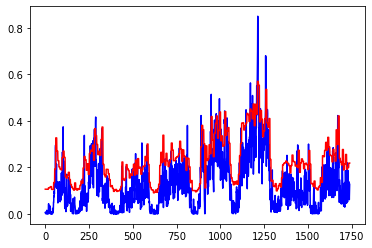

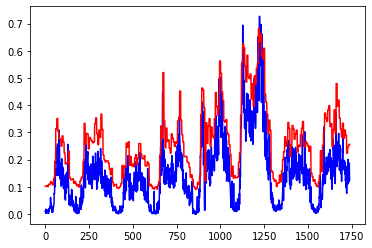

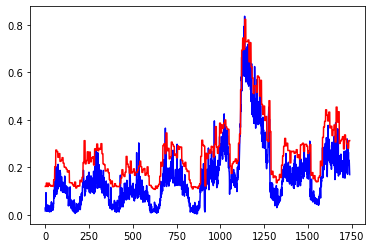

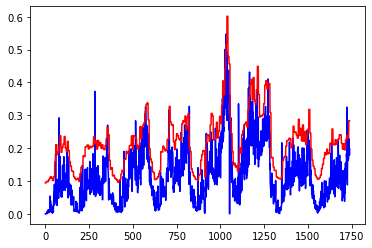

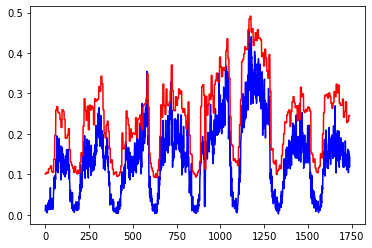

In [103]:
for SERVICE in range(5):
    plt.figure()
    plt.plot(x_test_norm[6:-4, SERVICE], 'b') 
    plt.plot(load_forecasted[:, SERVICE].mean(axis=-1), 'r')
    #plt.xlim([600, 1000])
plt.show()

In [46]:
def tsplot(x, y, ax=plt, lw=1, n=20, step_plot=None, percentile_min=0, percentile_max=100, color='r', 
           plot_mean=True, plot_median=False, mean_color='k', median_color='k',
           label='None',edgecolor='None', **kwargs):
    # calculate the lower and upper percentile groups, skipping 50 percentile
    perc1 = np.percentile(y, np.linspace(percentile_min, 50, num=n, endpoint=False), axis=-1)
    perc2 = np.percentile(y, np.linspace(50, percentile_max, num=n+1)[1:], axis=-1)

    if 'alpha' in kwargs:
        alpha = kwargs.pop('alpha')
    else:
        alpha = 1/n
    # fill lower and upper percentile groups
    lbl = None
    if n == 1:
        lbl = f'{label} [{percentile_min}th,{percentile_max}th] percentile'
    for p1, p2 in zip(perc1, perc2):
        
        ax.fill_between(x, p1, p2, alpha=alpha, color=color, edgecolor=edgecolor,
                         label=lbl, step=step_plot)


    if plot_mean:
        if step_plot is None:
            ax.plot(x, np.mean(y, axis=-1), color=mean_color, lw=lw, label=label)
        else:
            ax.step(x, np.mean(y, axis=-1), color=mean_color, lw=lw, label=label, where=step_plot)


    if plot_median:
        if step_plot is None:
            ax.plot(x, np.median(y, axis=-1), color=median_color, lw=lw, label=label)
        else:
            ax.step(x, np.median(y, axis=-1), color=median_color, lw=lw, label=label, where=step_plot)
    
    return plt.gca()

In [47]:
colors = ['#0377fc','#eb4034', '#52d411', '#e810d2', '#ff9e03', '#00d5ff']

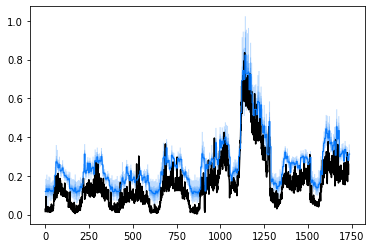

In [105]:
SEL_SERV = 2

plt.plot(x_test_norm[6:-10, SEL_SERV], 'k')
tsplot(np.arange(0, 1740), load_forecasted[:, SEL_SERV],
           percentile_min=1, percentile_max=100, n=4, color=colors[0], 
           mean_color=colors[0], plot_mean=True, label='PROVA', 
           step_plot='post', lw = 1)
#plt.plot(load_forecasted.mean(axis=-1), 'r')
#plt.xlim([0, 1000])
plt.show()

In [106]:
np.save(f'./Results/Bordeaux/Th_6/cap_fore_uncer_test_block1_delay_{DELAY}_phi_{PHI}_gamma_{GAMMA}_deltax_005.npy',
        load_forecasted)

# Training forecast creation

In [117]:
training_load_forecasted = np.zeros((2687, 5, B))

for idx, inputs in enumerate(input_dataset):
    #print(idx, inputs.shape)
    for i in range(B):
        try:
            training_load_forecasted[idx * 128: (idx+1)*128, :, i] = model.predict(inputs)
        except ValueError:
            print(idx)
        
training_load_forecasted = np.repeat(training_load_forecasted, DELAY, axis=0)

In [118]:
np.save(f'./Results/Bordeaux/Th_6/cap_fore_uncer_training_block1_delay_{DELAY}_phi_{PHI}_gamma_{GAMMA}_deltax_005.npy',
        training_load_forecasted)

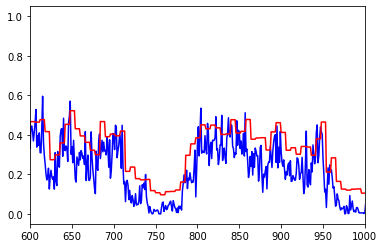

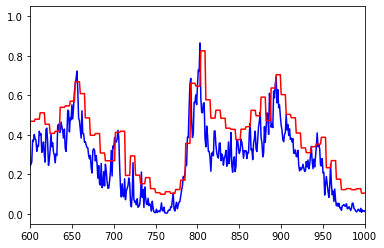

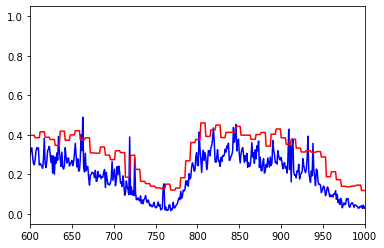

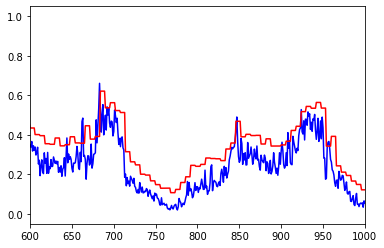

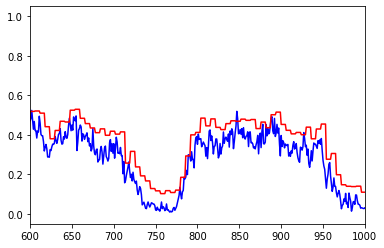

In [121]:
for SERVICE in range(5):
    plt.figure()
    plt.plot(x_train_norm[6:-4, SERVICE], 'b')
    plt.plot(training_load_forecasted[:, SERVICE].mean(axis=-1), 'r')
    plt.xlim([600, 1000])
plt.show()

# Saving minmaxscaler

In [129]:
import pickle

In [130]:
pickle.dump(minmaxscaler, open('./Results/Bordeaux/Th_6/block_1_minmaxscaler.pkl', 'wb'))